In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [3]:
# Step 3 - Preprocess the images

import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Path to your dataset folder
dataset_path = r"C:\Users\USER-PC\Desktop\cats_vs_dogs"

# Resize all images to 150x150 and scale pixel values to 0-1
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2  # 20% of images used for validation
)

# Training data
train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

# Validation data
val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

print(train_data.class_indices)

Found 96 images belonging to 2 classes.
Found 24 images belonging to 2 classes.
{'cats': 0, 'dogs': 1}


In [4]:
# Step 5 - Build the CNN model

from tensorflow.keras import models, layers

model = models.Sequential([
    # First Convolutional Layer - detects basic features like edges
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D(2, 2),

    # Second Convolutional Layer - detects more complex features
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    # Third Convolutional Layer - detects even more complex features
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    # Flatten and connect to output
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # 1 output - cat or dog
])

model.summary()

C:\Users\USER-PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 36992)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │      18,940,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 19,034,177 (72.61 MB)

 Trainable params: 19,034,177 (72.61 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Step 6 - Compile the model

model.compile(
    loss='binary_crossentropy',  # measures how wrong the model is
    optimizer='adam',            # method for correcting mistakes
    metrics=['accuracy']         # we want to track accuracy
)

print("Model compiled successfully!")

Model compiled successfully!


In [6]:
# Step 7 - Train the model

history = model.fit(
    train_data,
    epochs=10,
    validation_data=val_data
)

print("Training complete!")

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 43s 8s/step - accuracy: 0.4792 - loss: 1.5751 - val_accuracy: 0.5000 - val_loss: 1.0792
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 4s/step - accuracy: 0.5417 - loss: 0.8454 - val_accuracy: 0.5833 - val_loss: 0.6804
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 4s/step - accuracy: 0.6667 - loss: 0.6657 - val_accuracy: 0.5417 - val_loss: 0.6678
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 4s/step - accuracy: 0.5938 - loss: 0.6514 - val_accuracy: 0.5417 - val_loss: 0.6705
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 4s/step - accuracy: 0.5833 - loss: 0.5830 - val_accuracy: 0.5417 - val_loss: 0.6418
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 4s/step - accuracy: 0.8438 - loss: 0.5139 - val_accuracy: 0.6250 - val_loss: 0.6369
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 4s/step - accuracy: 0.8229 - loss: 0.4293 - val_accuracy: 0.5417 - val_loss: 0.6763
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 4s/step - accuracy: 0.8958 - loss: 0.3256 - val_accuracy: 0.5833 - val_loss: 0.7042
Epoch 9/

In [7]:
# Step 8 - Evaluate the model

loss, accuracy = model.evaluate(val_data)

print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy * 100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 932ms/step - accuracy: 0.6667 - loss: 0.7787
Validation Loss: 0.7787
Validation Accuracy: 66.67%


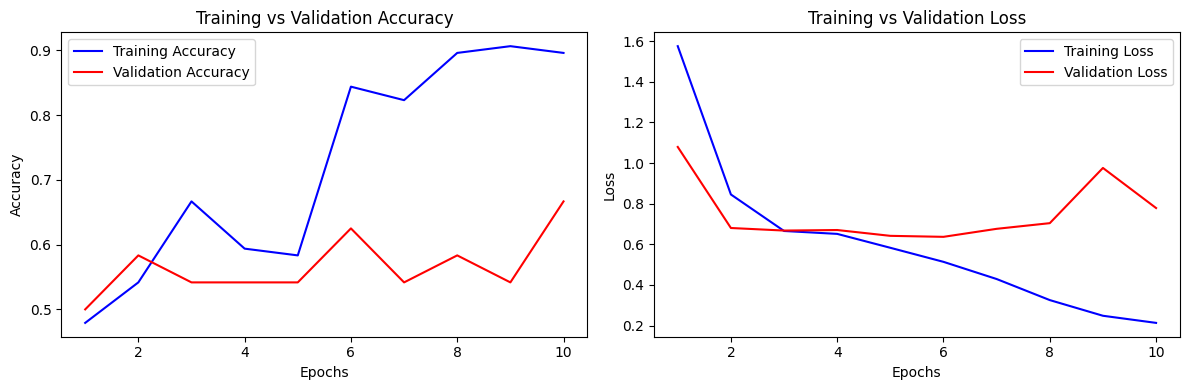

In [8]:
# Step 9 - Plot the results

import matplotlib.pyplot as plt

# Get the data from training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, 11)

# Plot accuracy
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'b', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'b', label='Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


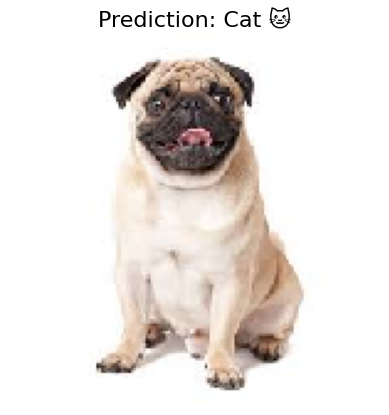

Prediction: Cat 🐱


In [9]:
# Step 10 - Make predictions

from tensorflow.keras.preprocessing import image
import numpy as np

# Load the test image
test_image_path = r"C:\Users\USER-PC\Desktop\test_image.jpg"
img = image.load_img(test_image_path, target_size=(150, 150))

# Prepare the image for the model
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

# Make prediction
prediction = model.predict(img_array)

# Interpret result
if prediction[0][0] > 0.5:
    result = "Dog 🐶"
else:
    result = "Cat 🐱"

# Display image with prediction
plt.imshow(img)
plt.title(f"Prediction: {result}", fontsize=16)
plt.axis('off')
plt.show()

print(f"Prediction: {result}")